<a href="https://colab.research.google.com/github/alinas-git/Loan-Default-Analysis-Prediction/blob/main/LoanDefaultPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

importing the libraries

In [237]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

loading the dataset

In [238]:
from google.colab import drive
drive.mount('/content/drive')
df=pd.read_csv("/content/drive/My Drive/Colab Notebooks/Loan_default.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Data Overview

In [239]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


exploring the dataset's insights

In [240]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [241]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [242]:
df.isnull().sum()

,0
LoanID,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
MonthsEmployed,0
NumCreditLines,0
InterestRate,0
LoanTerm,0
DTIRatio,0


#Data Cleaning

In [243]:
for col in ["HasMortgage","HasDependents",'HasCoSigner']:
  df[col]=df[col].map({'Yes':1,"No":0})

In [245]:
df['HasCoSigner'].unique()

array([1, 0])

#Exploritry Data Analysis (EDA)

SETUP FOR PLOTTING

In [246]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize":(14,6),
    "axes.titlepad":10,
    "axes.titleweight":"bold",
    "axes.labelweight":"semibold",
    "axes.labelpad":10,
    "axes.titlecolor": "#301934",
    "axes.titlesize":14,
    "axes.labelsize":12,
    "grid.alpha":0.4,
    "grid.linestyle":"--",
    "grid.color":"pink",
    "grid.linewidth":2,
    "axes.grid":True
    })


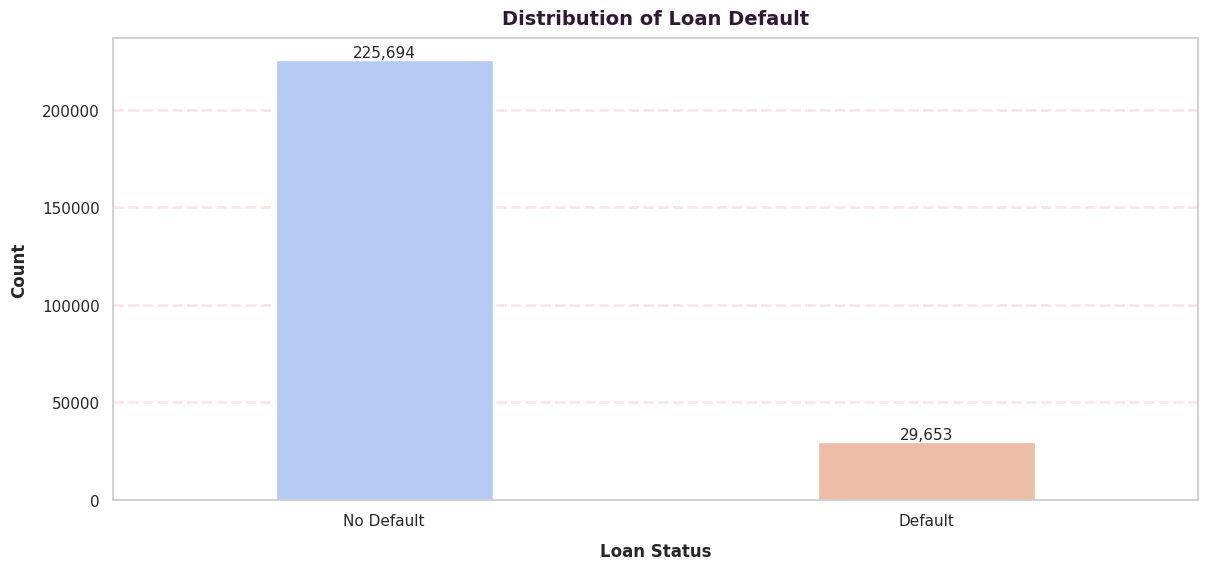

In [247]:
ax=sns.countplot(x="Default",data=df,
              palette="coolwarm",
              width=0.4)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',size=11)

plt.title("Distribution of Loan Default")
plt.xticks([0,1],["No Default","Default"])
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

#Analysis Of Class Imbalance



*   The Gap here is massive, the "No Default" group vastly outnumbers the "Default" group (225,694 vs 29,653).
* Non-defaulters make up approximately 88% of the total data
* Since the Default class is the minority, for our model we must focus on Recall (catching as many defaults as possible) & the F1-Score rather than just overall accuracy.



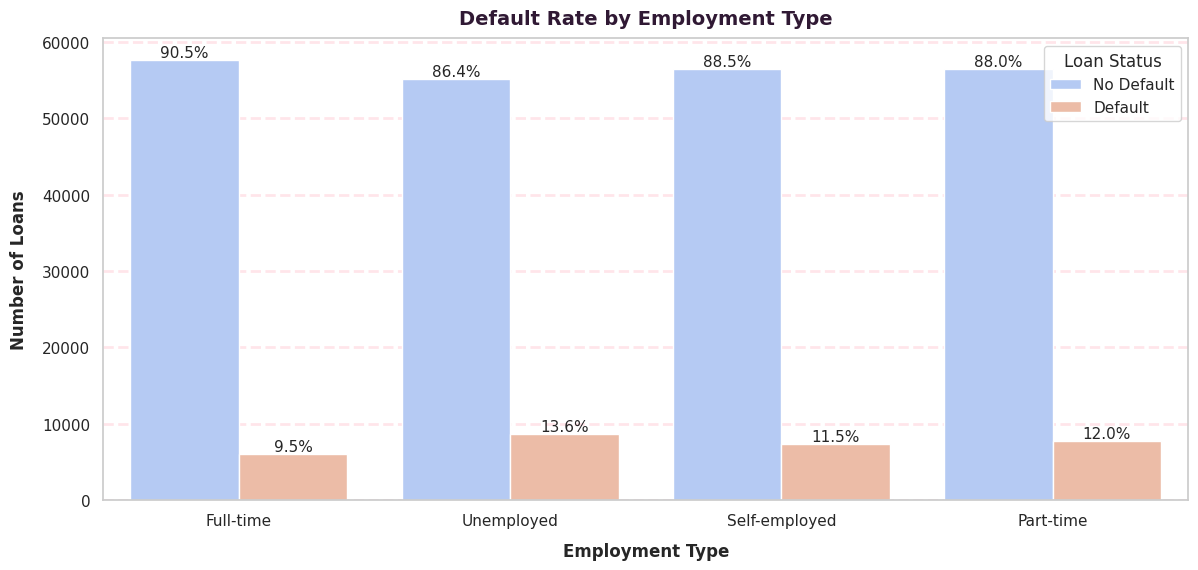

In [248]:
totals = df.groupby('EmploymentType').size()
ax = sns.countplot(x='EmploymentType', hue='Default', data=df, palette='coolwarm')

for p in ax.patches:
    height = p.get_height()
    if height > 0:

        x = p.get_x() + p.get_width() / 2
        Cat = df['EmploymentType'].unique()[int(round(x))]

        total = totals[Cat]
        percentage = 100 * height / total
        ax.annotate(f'{percentage:.1f}%',
                    (p.get_x() + p.get_width()/2., height),
                    size=11,ha='center', va='bottom')

plt.title('Default Rate by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Number of Loans')
plt.legend(title='Loan Status', labels=['No Default', 'Default'])
plt.show()

INSIGHTS:

We can clearly see that the percentage of defualt varies by job status


*   Unemployed people have the highest rate at 13.6%.
*   Full-time employees have the lowest default rate at 9.5%.

Even tho the difference is not significant, The Full-time group is more likely to default




In [249]:
df['Employment_Length'] = pd.cut(
    df['MonthsEmployed'],
    bins=[0, 12, 36, 60, 120],
    labels=['<1 year', '1-3 years', '3-5 years', '5+ years']
)


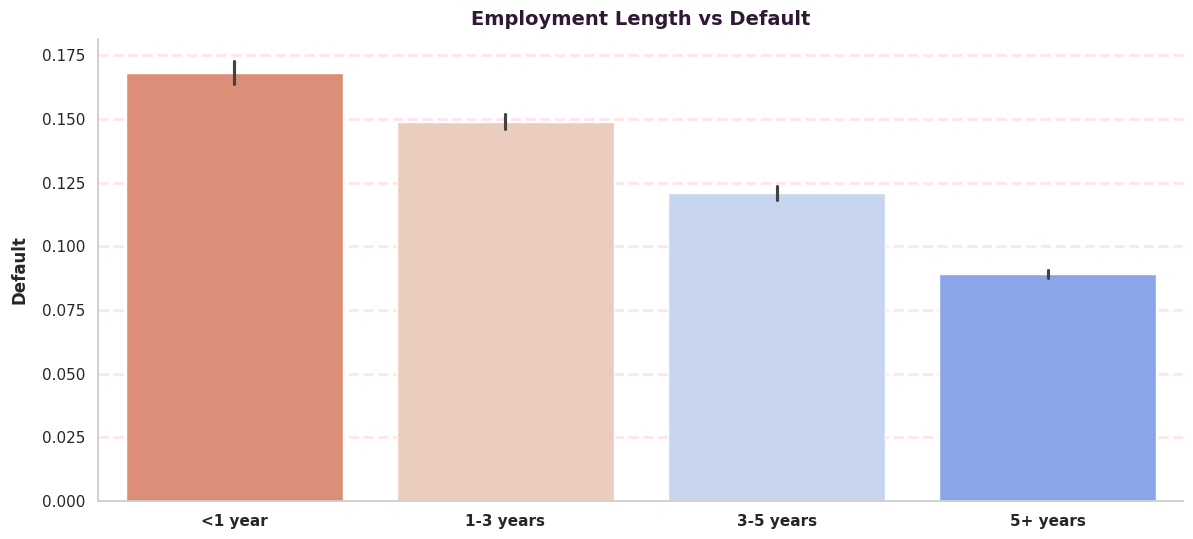

In [250]:
sns.barplot(data=df,x="Employment_Length",y="Default",palette="coolwarm_r")
plt.xlabel("")
plt.xticks(fontweight="semibold")
plt.title("Employment Length vs Default")
sns.despine()
plt.show()


INSIGHTS:
* As tenure increases, the probability of default drops significantly

* Applicants with <1 year of experience are almost twice as likely to default compared to those with 5+ years of experience.

* The risk of default peaks at 17% for those employed less than a year and steadily declines to being less than 10% for those with 5+ years of tenure.

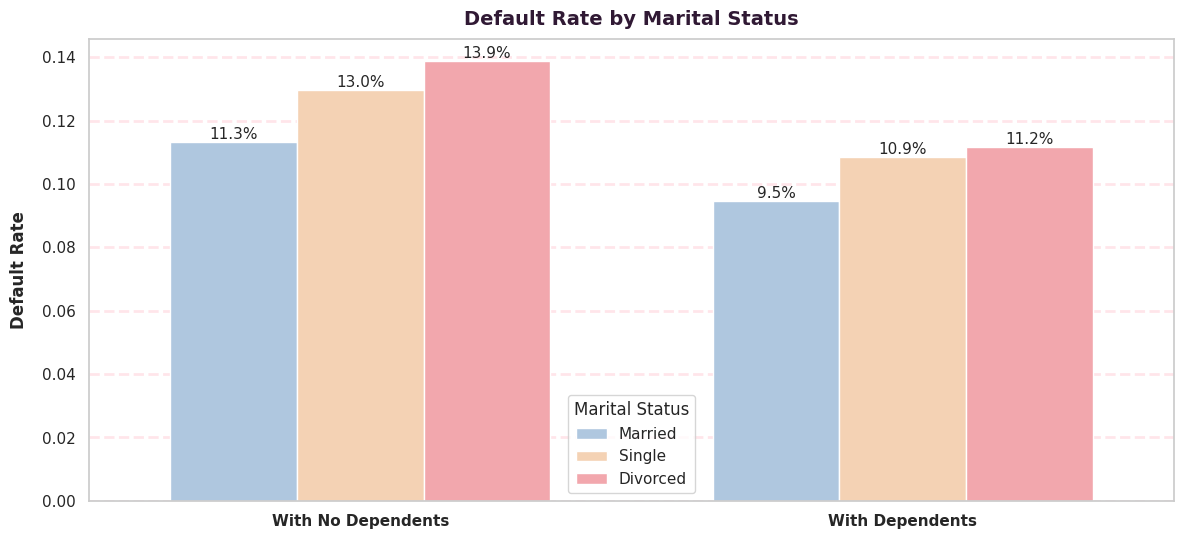

In [251]:
ax=sns.barplot(
    x='HasDependents',y='Default',hue="MaritalStatus",errorbar=None,data=df,palette = ['#A7C7E7','#FFD1A9', '#FF9AA2'],width=0.7)

for p in ax.patches:
  height=p.get_height()
  if height>0:
    ax.annotate(f'{height*100:.1f}%',
                 (p.get_x()+p.get_width()/2.,height),
                 ha="center",va="bottom",size=11)

plt.title('Default Rate by Marital Status')
plt.ylabel('Default Rate')
ax.set_xticklabels(["With No Dependents","With Dependents"],fontweight="semibold")
plt.legend(title="Marital Status",loc="lower center")
plt.xlabel('')
plt.show()

**Dependents effect:**

 People with dependents have lower defaults, likely because family responsibility pushes more careful financial behavior.

**No dependents:**

 Higher default rates suggest less financial pressure to stay disciplined.

**Marital Impact:**

* **Married:** Lowest risk, possibly due to shared income, shared expenses, and
better financial stability.

* **Divorced:** High Risk, 13.9% for those without dependents. The financial strain or lifestyle changes, & loss of shared economic support after separation.

* **Single:** Falling in the middle, single individuals show a moderate risk level.

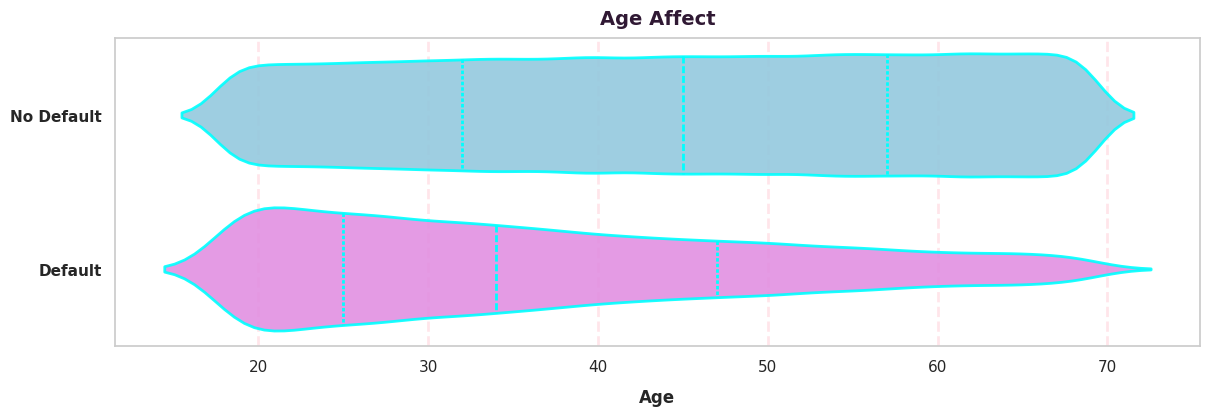

In [252]:
plt.figure(figsize=(14,4))

ax=sns.violinplot(data=df,x="Age",y="Default",orient="h",inner="quartile",linecolor="cyan",inner_kws={"color":"cyan"},
                   palette = ['skyblue', 'violet'],linewidth=2,alpha=0.9)

ax.set_yticklabels(["No Default","Default"],fontweight="semibold")
plt.title("Age Affect")
plt.ylabel("")
plt.show()

INSIGHTS:
* No Default (Blue): The shape is very thick and rectangular across almost all ages. Meaning people who pay back are evenly spread out across all age groups.

* As age increases, the purple violin gets thinner showing that 50-70 older borrowers are much less likely to default compared to 20-25 younger ones.

* Younger Borrowers: Defaults are heavily concentrated in the 20–30 age range.

* The vertical lines are a divide into 4 part, in the purple violin lines are shifted much further to the left, 50% of defaulters are before the age 34.

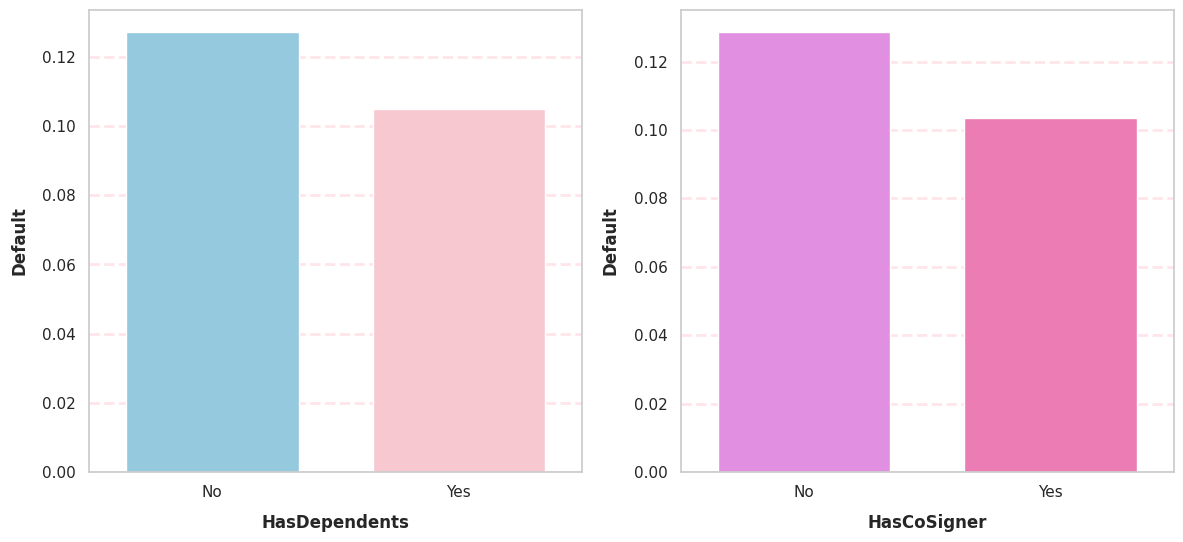

In [253]:
fig,axes=plt.subplots(1,2,figsize=(14,6))
ax1=sns.barplot(data=df,x="HasDependents",y="Default",errorbar=None,ax=axes[0],palette=["skyblue","pink"],width=0.7)
ax2=sns.barplot(data=df,x="HasCoSigner",y="Default",errorbar=None,ax=axes[1],palette=["violet","hotpink"],width=0.7)
ax1.set_xticklabels(["No","Yes"])
ax2.set_xticklabels(["No","Yes"])

plt.show()


INSIGHTS:
* borrowers who have dependents have Responsibility Effect, they have a lower default rate, likely because family responsibility leads to more careful financial behavior versus when an individual doesn't have dependents it generally leads to a higher default.


* individuals with a Co-Signer have a Security Effect, as their default is lower. as it provides legal and financial backup for repayment.

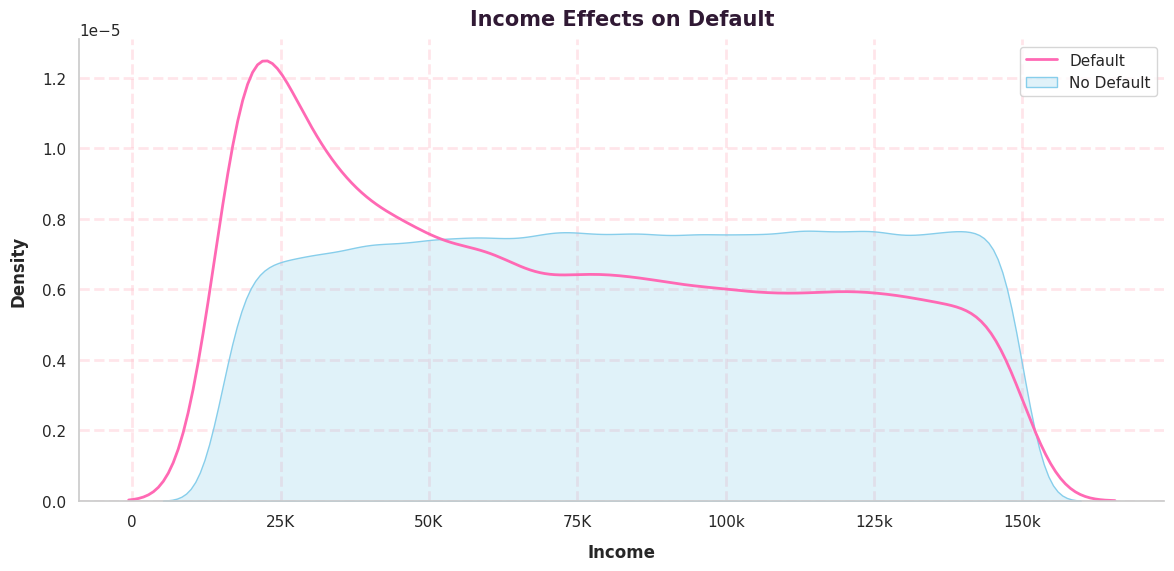

In [254]:
sns.kdeplot(data=df[df["Default"]==1],lw=2,x="Income",color="hotpink",label="Default")
sns.kdeplot(x="Income",data=df[df["Default"]==0],fill=True,color="skyblue",label="No Default")

plt.title("Income Effects on Default",size=15)
plt.xlabel("Income")
plt.legend()
plt.xticks([0,25000,50000, 75000,100000,125000,150000],['0','25K', '50K', '75K','100k','125k','150k'])
sns.despine()
plt.show()

Key Insights:
* The **pink defaults curve** spikes from the very start to around 25k, then drops quickly after ~25k.
  → Meaning: most people who struggle to repay are in the lowest income group.

* The **blue no default curve** stays spread out across incomes.
  → Meaning: people who repay exist at all income levels, not just high income.

Simple takeaway:

* Below ~25k → high financial stress zone → more defaults
* After ~$25k, it drops significantly, meaning default risk starts reducing quickly.

* After $75k, it becomes mostly flat and steady → indicating a safe zone for repayment stability

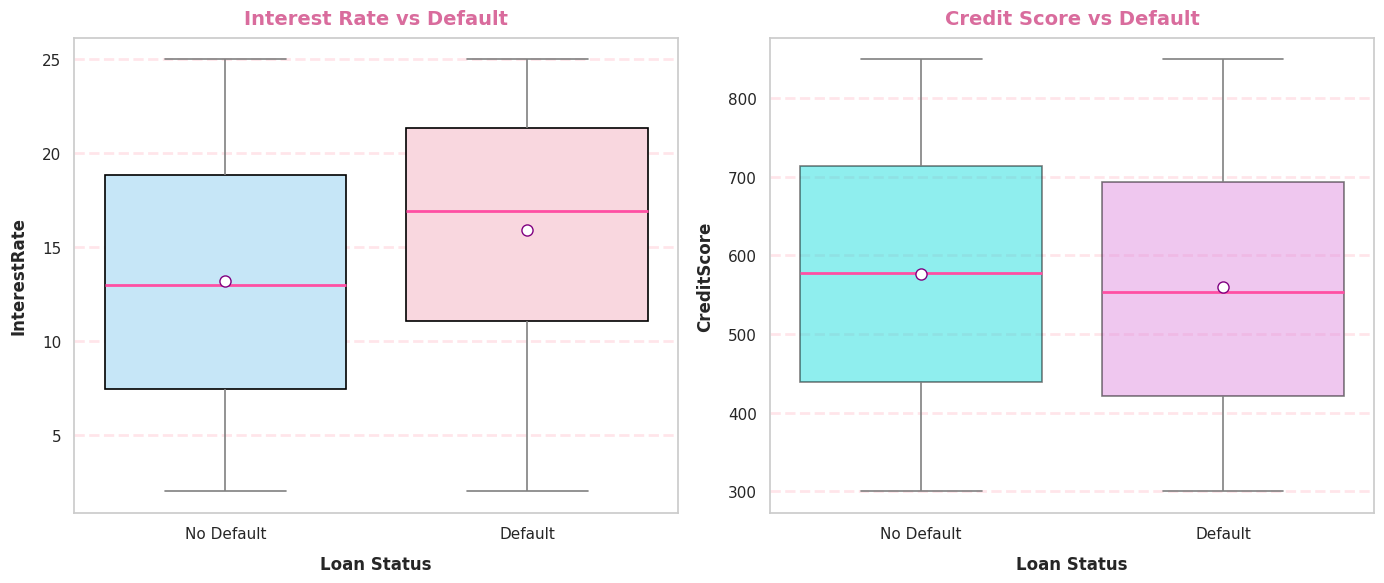

In [255]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.boxplot(
    ax=axes[0],x='Default',y='InterestRate',data=df,palette=['#BEE9FF', '#FFD1DC'],showmeans=True,
    meanprops={"marker":"o","mfc":"white","mec":"purple","ms":8},

    boxprops={'edgecolor':'black', 'lw':1.2},
    whiskerprops={'color':'gray', 'lw':1.2},
    capprops={'color':'gray', 'lw':1.2},
    medianprops={'color':'#FF4FA3', 'lw':2},
    flierprops={'marker':'o', 'mfc':'gray', 'alpha':0.3})

ax=sns.boxplot(
    ax=axes[1], x='Default',y='CreditScore',data=df,palette=['cyan','violet'],showmeans=True,
    meanprops={"marker":"o","mfc":"white","mec":"purple","ms":8},

    boxprops={'edgecolor':'black', 'linewidth':1.2},
    flierprops={ 'mfc':'gray', 'alpha':0.3,'marker':'o'},
    medianprops={'color':'#FF4FA3', 'lw':2},
    whiskerprops={'color':'gray', 'lw':1.2},
    capprops={'color':'gray', 'lw':1.2},)

for patch in ax.patches:
  patch.set_alpha(0.5)

axes[1].set_title('Credit Score vs Default', color="#D96C9D")
axes[1].set_xlabel("Loan Status")
axes[0].set_xlabel("Loan Status")
axes[1].set_xticklabels(['No Default', 'Default'])
axes[0].set_title('Interest Rate vs Default', color="#D96C9D")
axes[0].set_xticklabels(['No Default', 'Default'])

plt.tight_layout()
plt.show()

**Interest Rate**

* The center line in the box (median) represents the typical value of the group this line is higher For defaulted borrowers, meaning they generally have higher interest rates.

* For non-defaulted borrowers, the line is lower, meaning they usually get lower interest rates.

This shows that higher interest rates increase the chance of loan default, because repayment becomes more difficult with higher cost

**Credit Score**

* For defaulted borrowers the center line in the box is lower, meaning they usually have lower credit scores

* For non-defaulted borrowers, the line is higher, meaning they have better credit scores

This shows that lower credit scores indicate higher chance of default, because they reflect weaker repayment history

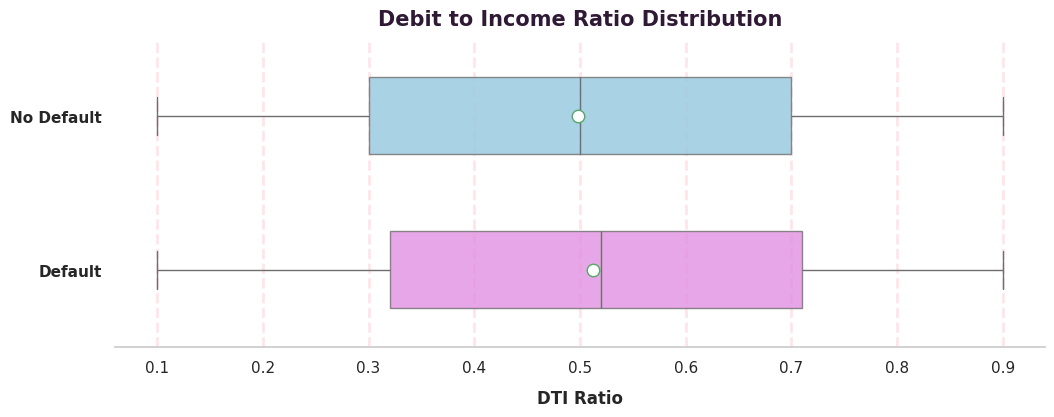

In [256]:
plt.figure(figsize=(12, 4))

ax = sns.boxplot(
    data=df, x="DTIRatio", y="Default", orient="h",hue="Default",showmeans=True, palette=['skyblue','violet'], legend=False,width=0.5, fliersize=2,
    meanprops={"marker":"o","mfc":"white","ms":9})
for p in ax.patches:
  p.set_alpha(0.8)

ax.set_yticklabels(["No Default", "Default"], fontweight="semibold")
plt.title("Debit to Income Ratio Distribution", fontsize=15, fontweight='bold')
plt.xlabel("DTI Ratio")
plt.ylabel("")
sns.despine(left=True)
plt.show()

This plot shows the DTI (Debt-to-Income) Ratio. It measures how much of a borrower's monthly income goes toward paying debts.

The solid line inside each box represents the Median 50 (percentile) and the middle value of the data.

The small white circle represents the Mean (the average).

* The purple Default box is shifted further to the right compared to the Blue No Default box.

* Default Group: Look closely at the purple box, the circle is slightly to the right of the Median, this means are more borrowers with high DTI ratios pushing the average up.

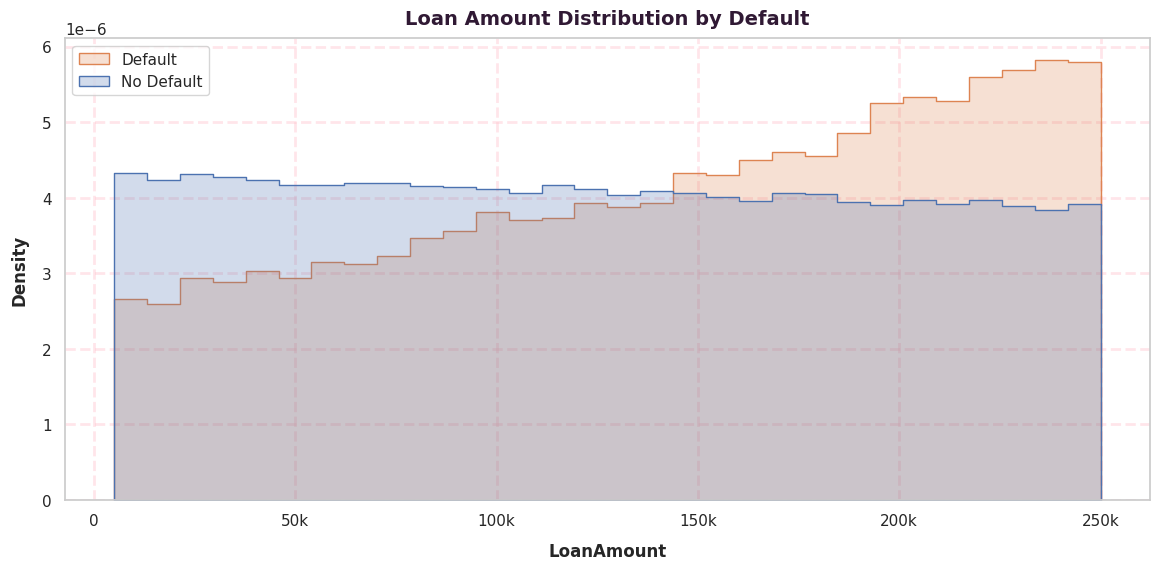

In [257]:
sns.histplot(
    data=df,
    x='LoanAmount',
    hue='Default',
    bins=30,
    element='step',
    stat='density',
    common_norm=False
)
plt.legend(labels=["Default","No Default"])
plt.title('Loan Amount Distribution by Default')

plt.xticks([0,50000,100000,150000,200000,250000],["0","50k",'100k','150k','200k',"250k"])
plt.show()

INSIGHTS:
* As the loan amount increases (towards 250k), the Red rises sharply which makes sense, larger loans are harder to pay back and represent a bigger financial burden.

* smaller loans under 50k have a much lower defaults. At lower amounts, the No Default or Blue group is the dominant category.

* There is a clear DANGER ZONE that starts after 125k. The red area (Default) begins to overtake the blue area, showing that the risk grows with every extra dollar borrowed.

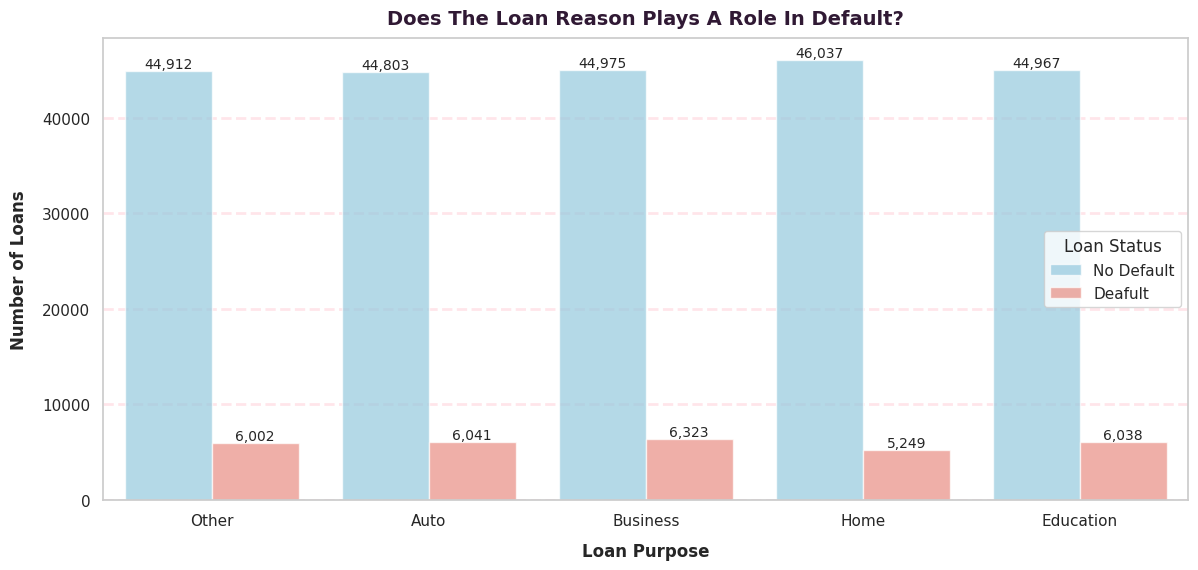

In [258]:
ax=sns.countplot(data=df,x="LoanPurpose",hue="Default",palette=["skyblue","salmon"],alpha=0.7)

for p in ax.patches:
  height=p.get_height()
  if height>0:
    percentage=f'{100*height/len(df):.1f}%'
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x()+p.get_width()/2,p.get_height()),
                ha="center",va="bottom",size=10)
plt.legend(title="Loan Status",labels=["No Default","Deafult"])
plt.title("Does The Loan Reason Plays A Role In Default?",size=14)
plt.ylabel("Number of Loans",size=12)
plt.xlabel("Loan Purpose",size=12)
plt.show()

#Encoding & Model Selection

In [259]:
X=df.drop(["Employment_Length","LoanID","Default"],axis=1)
y=df["Default"]

In [260]:
X=pd.get_dummies(X,drop_first=True)

In [261]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# 1.Logestic Regression

In [262]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [263]:
y_pred=model.predict(X_test)

In [264]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.64      0.01      0.02      5900

    accuracy                           0.88     51070
   macro avg       0.76      0.50      0.48     51070
weighted avg       0.86      0.88      0.83     51070



In [265]:
print(confusion_matrix(y_test,y_pred))


[[45140    30]
 [ 5846    54]]


Balancing the class weight

In [266]:
model=LogisticRegression(max_iter=1000,class_weight="balanced")
model.fit(X_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [267]:
y_pred=model.predict(X_test)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.67      0.79     45170
           1       0.21      0.68      0.33      5900

    accuracy                           0.67     51070
   macro avg       0.58      0.68      0.56     51070
weighted avg       0.86      0.67      0.73     51070

[[30464 14706]
 [ 1898  4002]]


# 2.XGBoost

In [268]:
from xgboost import XGBClassifier
XGB=XGBClassifier(scale_pos_weight=45139/5931,random_state=42)
XGB.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [269]:
y_XGBpred=XGB.predict(X_test)
print(classification_report(y_test,y_XGBpred))

              precision    recall  f1-score   support

           0       0.94      0.73      0.82     45170
           1       0.23      0.62      0.34      5900

    accuracy                           0.72     51070
   macro avg       0.58      0.67      0.58     51070
weighted avg       0.85      0.72      0.76     51070



Trying different Thresholds

In [270]:
XGB_yprob=XGB.predict_proba(X_test)[:,1]

In [271]:
for i in [0.4,0.5,0.6,0.7,0.8]:
  temp_ypred=(XGB_yprob>i).astype(int)
  print(f"\n\nThreshold:{i}\n")
  print(classification_report(y_test,temp_ypred))
  print(confusion_matrix(y_test,temp_ypred))




Threshold:0.4

              precision    recall  f1-score   support

           0       0.95      0.60      0.73     45170
           1       0.20      0.74      0.31      5900

    accuracy                           0.62     51070
   macro avg       0.57      0.67      0.52     51070
weighted avg       0.86      0.62      0.69     51070

[[27071 18099]
 [ 1506  4394]]


Threshold:0.5

              precision    recall  f1-score   support

           0       0.94      0.73      0.82     45170
           1       0.23      0.62      0.34      5900

    accuracy                           0.72     51070
   macro avg       0.58      0.67      0.58     51070
weighted avg       0.85      0.72      0.76     51070

[[32965 12205]
 [ 2257  3643]]


Threshold:0.6

              precision    recall  f1-score   support

           0       0.93      0.84      0.88     45170
           1       0.28      0.48      0.35      5900

    accuracy                           0.80     51070
   macro avg   

Setting the final Threshold

In [272]:
XGB_yprob=XGB.predict_proba(X_test)[:,1]
XGB_ypred=(XGB_yprob>0.6).astype(int)
print(classification_report(y_test,XGB_ypred))
print(confusion_matrix(y_test,y_XGBpred))

              precision    recall  f1-score   support

           0       0.93      0.84      0.88     45170
           1       0.28      0.48      0.35      5900

    accuracy                           0.80     51070
   macro avg       0.60      0.66      0.62     51070
weighted avg       0.85      0.80      0.82     51070

[[32965 12205]
 [ 2257  3643]]


7. Model Comparison & Selection:

The XGBoost with threshold of 0.6 is the perfect balance of recall and precision, ensuring most defaulters are identified with a limited false positive.

identifing high-risk customers while reducing unnecessary rejection of low-risk applicants compared to more aggressive thresholds.

In [273]:
featureDF=pd.DataFrame({
    "Feature":X.columns,
    "Importance":XGB.feature_importances_})
featureDf=featureDF.sort_values(by="Importance",ascending=False)
featureDf.head(10)

,Feature,Importance
0,Age,0.116658
11,HasCoSigner,0.068982
6,InterestRate,0.066241
1,Income,0.059057
17,EmploymentType_Unemployed,0.056463
10,HasDependents,0.051919
4,MonthsEmployed,0.049173
2,LoanAmount,0.046819
18,MaritalStatus_Married,0.042030
22,LoanPurpose_Home,0.039341


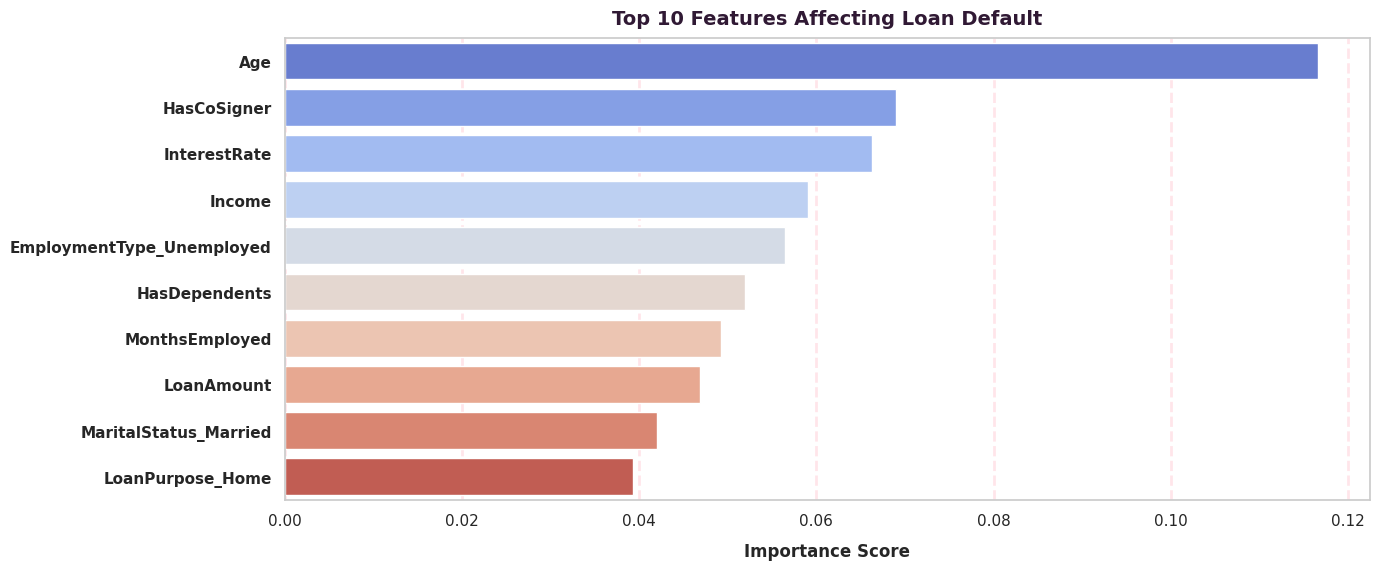

In [274]:
sns.barplot(orient="h",data=featureDf.head(10),x="Importance",y="Feature",palette="coolwarm")
plt.ylabel("")
plt.title("Top 10 Features Affecting Loan Default")
plt.yticks(fontweight="semibold")
plt.xlabel("Importance Score")
plt.show()

# Wrap up & Final Model Conclusion
### XGBoost at 0.6 threshold has a Balanced performance for real-world risk
* The model doesn’t just aim for accuracy, it focuses on catching risky borrowers (defaults).

Strong recall for defaults (0.48)

* It successfully identifies a large portion of actual defaulters, which is crucial for reducing financial loss.

Controlled false alarms (Precision 0.28)

* While it flags some safe borrowers as risky, this is acceptable in lending because missing a defaulter is worse than flagging a safe applicant.

High overall accuracy (80%)

* Shows the model still performs strongly across both classes.
Business-aligned threshold tuning

* Using 0.6 threshold improves risk sensitivity, making the model more practical for loan approval decisions instead of just theoretical performance.